In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')



In [211]:

# 3.1 Load Data
data_path = "Student_performance_data .csv"
df = pd.read_csv(data_path)



In [212]:
# Display first few rows
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [213]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [214]:
df.isna().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [215]:
# Summary statistics
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [216]:
# Let's also look at unique values in GradeClass
print("GradeClass Unique Values:", df['GradeClass'].unique())

GradeClass Unique Values: [2. 1. 4. 3. 0.]


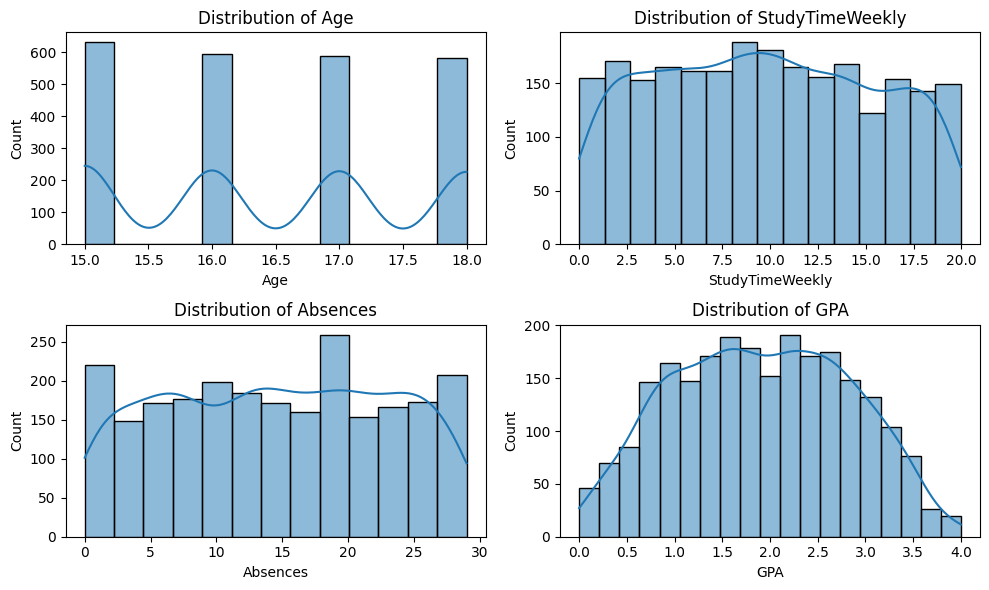

In [217]:
numerical_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

plt.figure(figsize=(10,6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


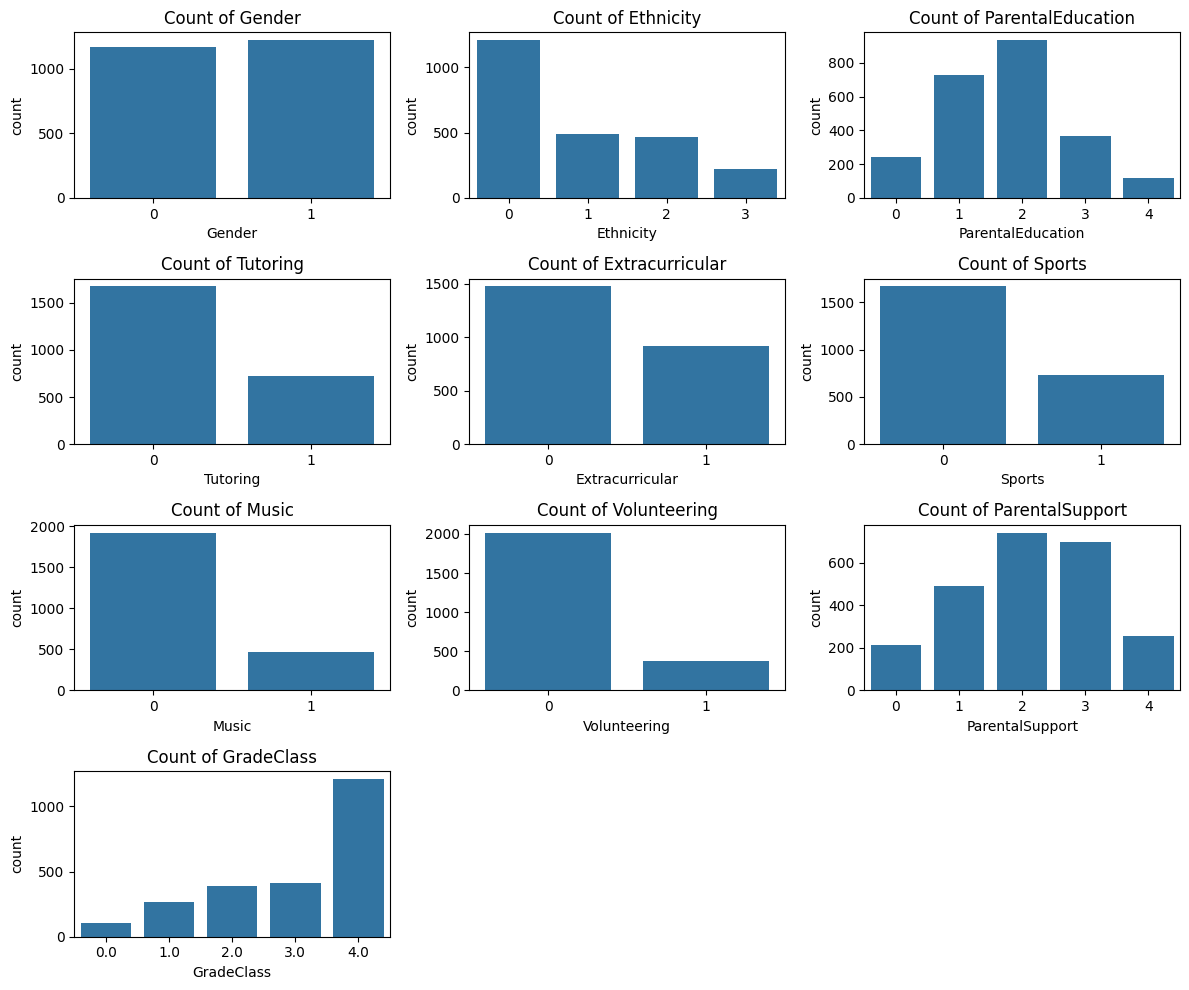

In [218]:
categorical_cols = ['Gender','Ethnicity','ParentalEducation','Tutoring','Extracurricular',
                    'Sports','Music','Volunteering','ParentalSupport','GradeClass']

plt.figure(figsize=(12,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4,3,i+1)
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()

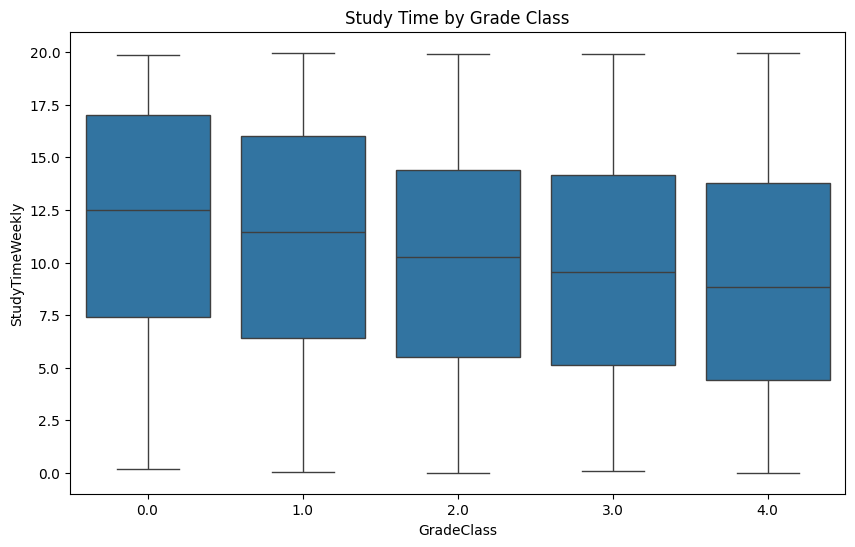

In [219]:
# For numeric vs. GradeClass
plt.figure(figsize=(10,6))
sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df)
plt.title("Study Time by Grade Class")
plt.show()

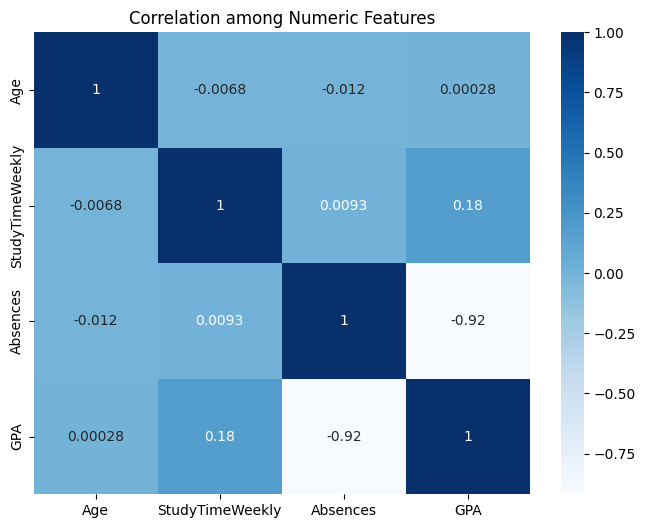

In [220]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation among Numeric Features")
plt.show()

# Data Preparation & Cleaning

In [221]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [222]:
# Example: If minimal missing, fill numeric with median and categorical with mode
numeric_cols = ['Age','StudyTimeWeekly','Absences','GPA']  # If 'GPA' is in the dataset
categorical_cols = ['Gender','Ethnicity','ParentalEducation','ParentalSupport',
                    'Tutoring','Extracurricular','Sports','Music','Volunteering','GradeClass']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

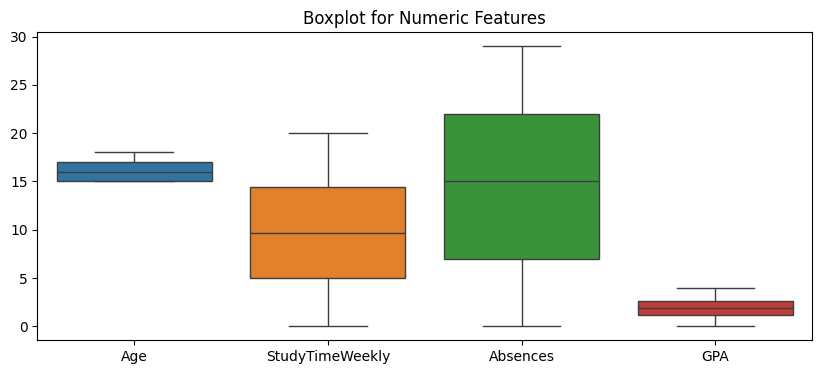

In [223]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot for Numeric Features")
plt.show()

# Feature Engineering

In [224]:
df.drop('GPA', axis=1, inplace=True)
df['TotalExtracurricular'] = (df['Sports'] + df['Music'] + df['Volunteering'])
# df['HasAnyExtracurricular'] = df['TotalExtracurricular'].apply(lambda x: 1 if x > 0 else 0)
df['ParentalEduSupport'] = df['ParentalEducation'] * df['ParentalSupport']


In [225]:
# df['AbsenceLevel'] = pd.cut(df['Absences'], bins=[-1, 5, 15, 30], labels=[1, 2, 3])


Exclude GPA (to avoid direct leakage of GradeClass)
Since GradeClass is derived from GPA, we typically remove GPA from the feature set. Otherwise, the model will cheat by effectively reading the answer directly.

Combine Extracurricular Features
Sometimes, we want to know if a student is doing multiple extracurriculars. Let’s create a new feature for “total number of extracurricular activities.”

Interaction Between Parental Education & Support
ParentalEducation is coded (0=none, 1=High School, 2=Some College, 3=Bachelor’s, 4=Higher Study) and ParentalSupport is (0=None, 1=Low, 2=Moderate, 3=High, 4=Very High). Let’s create a product that might capture synergy:
(Higher product might mean a parent with advanced education and high support, which could significantly influence performance.)

In [226]:
# df = pd.get_dummies(df, columns=['Ethnicity'], prefix='Ethnicity')

Encoding Ethnicity (One-Hot Encoding)
Ethnicity has categories (0=Caucasian, 1=African American, 2=Asian, 3=Other). Since it’s not ordinal, it’s often better to one-hot encode:
This creates columns like Ethnicity_0, Ethnicity_1, Ethnicity_2, Ethnicity_3.

Important: The rest of our categorical columns (Gender, Tutoring, etc.) are mostly binary (0 or 1) or ordinal in a numeric sense. So we can keep them as is.

In [227]:
if 'StudentID' in df.columns:
    df.drop('StudentID', axis=1, inplace=True)

Check and Drop Non-Predictive Columns
Columns like StudentID (if present) do not help with prediction:

# Exploratory Data Analysis (EDA)

### Univariate Analysis

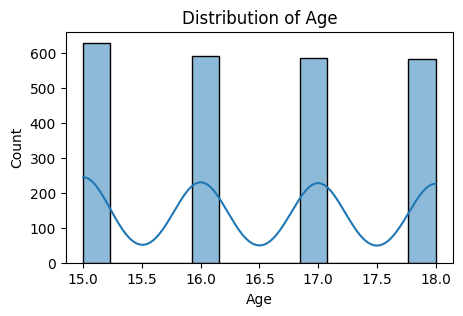

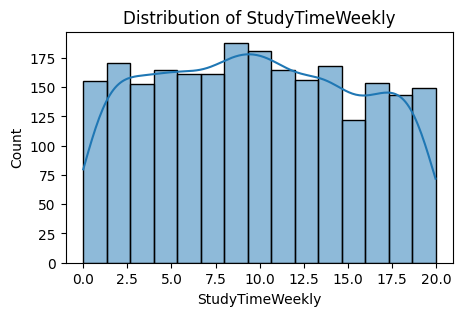

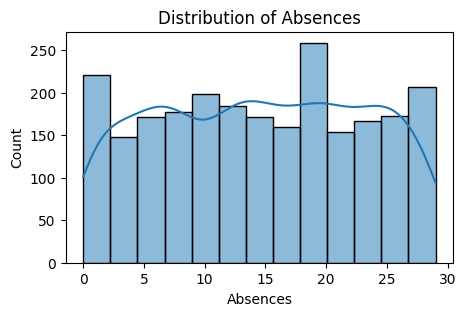

In [228]:
# Numeric distribution
numeric_feats = ['Age','StudyTimeWeekly','Absences']  # (we dropped GPA)
for col in numeric_feats:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


Check how each numeric feature is distributed. You might see if Absences is skewed

### Bivariate Analysis

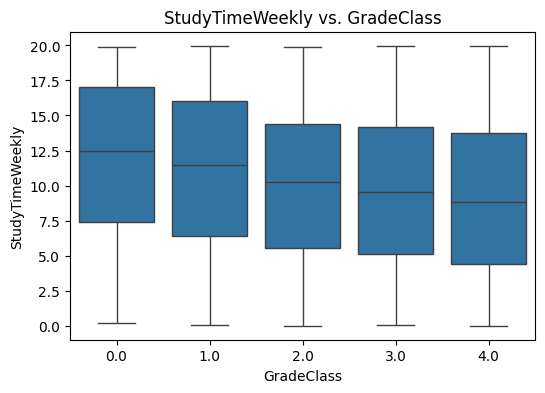

In [229]:
plt.figure(figsize=(6,4))
sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df)
plt.title("StudyTimeWeekly vs. GradeClass")
plt.show()


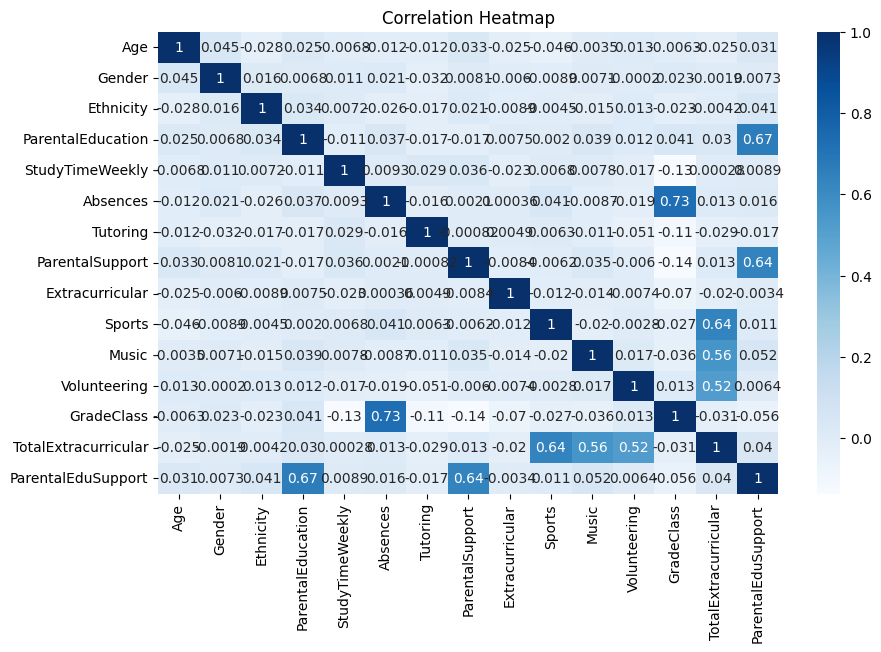

In [230]:
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


In [231]:
df

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass,TotalExtracurricular,ParentalEduSupport
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.0,1,4
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,1.0,0,1
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,4.0,0,6
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,3.0,0,9
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,4.0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,0.0,0,12
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,4.0,1,4
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,2.0,1,4
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.0,2,0


# Train/Test Split & Scaling

In [232]:
y = df['GradeClass'].values
X = df.drop('GradeClass', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [233]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), X.select_dtypes(include=['float64', 'int64']).columns),
    ('cat', OneHotEncoder(), X.select_dtypes(include=['object']).columns)
])

In [234]:
# # Identify numeric columns in X (exclude newly created one-hot columns for ethnicity)
# numeric_columns = ['Age','StudyTimeWeekly','Absences','TotalExtracurricular','ParentalEduSupport']
# # Some of these are already 0/1 or small integers. Strictly speaking, you can choose not to scale binary columns.
# # For demonstration, we show how to scale the numeric features that can vary widely.

# scaler = StandardScaler()
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
# X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])


We now scale only the numeric columns in X to help certain models converge better (especially neural networks or distance-based models). We’ll keep categorical columns unscaled.

# Baseline Machine Learning Models

In [235]:
def confusionMatrix(cm):
    labels = ['A', 'B', 'C', 'D', 'F']

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix")
    plt.ylabel('Actual Grade')
    plt.xlabel('Predicted Grade')
    plt.show()

Logistic Regression Accuracy: 0.7244258872651357
              precision    recall  f1-score   support

         0.0       0.38      0.14      0.21        21
         1.0       0.52      0.43      0.47        54
         2.0       0.50      0.67      0.57        78
         3.0       0.59      0.46      0.52        83
         4.0       0.90      0.95      0.92       243

    accuracy                           0.72       479
   macro avg       0.58      0.53      0.54       479
weighted avg       0.71      0.72      0.71       479



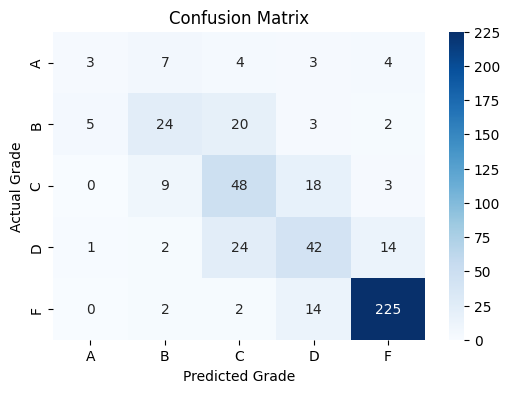

In [236]:
from sklearn.pipeline import Pipeline

log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
lr_pred = log_pipeline.predict(X_test)
lr_cm = confusion_matrix(y_test, rf_preds)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

confusionMatrix(lr_cm)

Random Forest Accuracy: 0.7139874739039666
Classification Report:
               precision    recall  f1-score   support

         0.0       0.33      0.14      0.20        21
         1.0       0.55      0.44      0.49        54
         2.0       0.49      0.62      0.55        78
         3.0       0.53      0.51      0.52        83
         4.0       0.91      0.93      0.92       243

    accuracy                           0.71       479
   macro avg       0.56      0.53      0.53       479
weighted avg       0.71      0.71      0.71       479



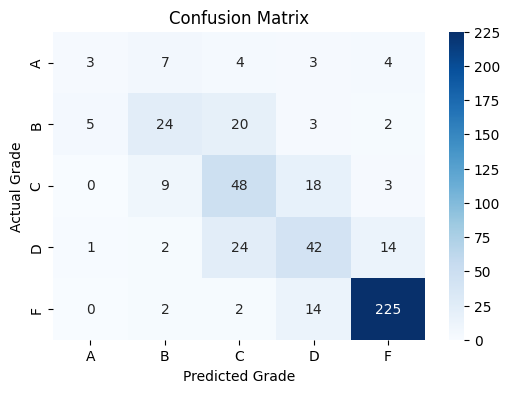

In [237]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_cm = confusion_matrix(y_test, rf_preds)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Classification Report:\n", classification_report(y_test, rf_preds))

confusionMatrix(rf_cm)

XGBoost Accuracy: 0.6847599164926931
Confusion Matrix:
 [[  5   6   2   4   4]
 [  6  29  14   3   2]
 [  0  13  41  23   1]
 [  0   3  26  40  14]
 [  0   3   2  25 213]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.45      0.24      0.31        21
         1.0       0.54      0.54      0.54        54
         2.0       0.48      0.53      0.50        78
         3.0       0.42      0.48      0.45        83
         4.0       0.91      0.88      0.89       243

    accuracy                           0.68       479
   macro avg       0.56      0.53      0.54       479
weighted avg       0.69      0.68      0.69       479



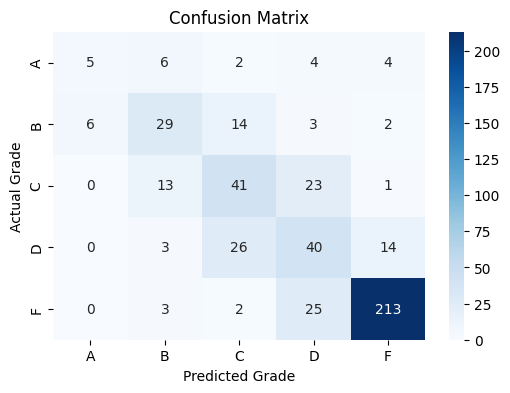

In [238]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)
xgb_cm = confusion_matrix(y_test, xgb_preds)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("Confusion Matrix:\n", xgb_cm)
print("Classification Report:\n", classification_report(y_test, xgb_preds))

confusionMatrix(xgb_cm)

# Deep Learning Model

In [239]:
num_classes = 5
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


In [240]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])


### Train the Model

In [241]:
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=20, 
    batch_size=16,
    verbose=1
)


Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4115 - loss: 1.4339 - val_accuracy: 0.5065 - val_loss: 1.1849
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5232 - loss: 1.1470 - val_accuracy: 0.5979 - val_loss: 0.9938
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6099 - loss: 0.9590 - val_accuracy: 0.6449 - val_loss: 0.9161
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6653 - loss: 0.8906 - val_accuracy: 0.6527 - val_loss: 0.8962
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7069 - loss: 0.8224 - val_accuracy: 0.6997 - val_loss: 0.8770
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7370 - loss: 0.7769 - val_accuracy: 0.6841 - val_loss: 0.8699
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7377 - loss: 0.7787 - val_accuracy: 0.7154 - val_loss: 0.8592
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7364 - loss: 0.7881 - val_accuracy: 0.7050 - val_loss:

### Evaluate on Test Data

Test Accuracy (Neural Network): 0.7223381996154785
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Confusion Matrix:
 [[  2   9   2   4   4]
 [  7  23  20   2   2]
 [  0   8  54  14   2]
 [  0   2  23  40  18]
 [  0   3   0  13 227]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.22      0.10      0.13        21
         1.0       0.51      0.43      0.46        54
         2.0       0.55      0.69      0.61        78
         3.0       0.55      0.48      0.51        83
         4.0       0.90      0.93      0.92       243

    accuracy                           0.72       479
   macro avg       0.54      0.53      0.53       479
weighted avg       0.71      0.72      0.71       479



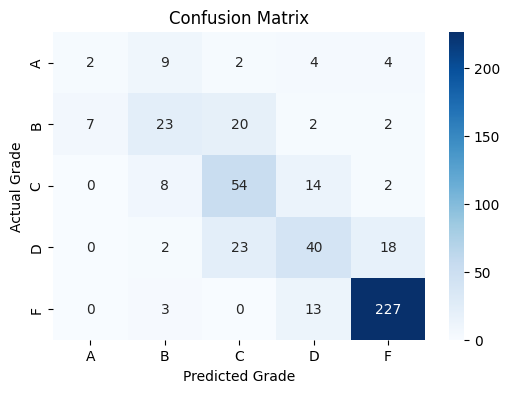

In [242]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("Test Accuracy (Neural Network):", test_acc)

# Confusion matrix and classification report
nn_preds_prob = model.predict(X_test_scaled)
nn_preds = np.argmax(nn_preds_prob, axis=1)
nn_cm = confusion_matrix(y_test, nn_preds)

print("Confusion Matrix:\n", nn_cm)
print("Classification Report:\n", classification_report(y_test, nn_preds))

confusionMatrix(nn_cm)

# Deployment

In [243]:
# # Conceptual deployment snippet (not a complete app)
# import dash
# from dash import html, dcc
# import pickle
# import numpy as np

# # Load your trained model
# # model = pickle.load(open("best_model.pkl","rb"))

# app = dash.Dash(__name__)

# app.layout = html.Div([
#     html.H1("BrightPath Grade Predictor"),
#     dcc.Input(id="age_input", type="number", placeholder="Age"),
#     dcc.Input(id="study_input", type="number", placeholder="StudyTimeWeekly"),
#     # ... more inputs ...
#     html.Button("Predict", id="predict_btn"),
#     html.Div(id="pred_output")
# ])

# @app.callback(
#     dash.dependencies.Output('pred_output', 'children'),
#     dash.dependencies.Input('predict_btn', 'n_clicks'),
#     [dash.dependencies.State('age_input', 'value'),
#      dash.dependencies.State('study_input', 'value'), 
#      # ... other states ...
#      ]
# )
# def predict_grade(n_clicks, age_val, study_val, ...):
#     if n_clicks:
#         # Prepare the data in the same format used in training
#         # sample = np.array([age_val, study_val, ...]).reshape(1, -1)
#         # sample_scaled = scaler.transform(sample)  # if you scaled in training
#         # pred = model.predict(sample_scaled)
#         # Return the predicted class
#         return f"Predicted Grade Class: {pred[0]}"
#     return ""

# if __name__ == '__main__':
#     app.run_server(debug=True)


# Modeling P2

In [244]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("GradeClass", axis=1))
y = df["GradeClass"]


## ML

In [245]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


## DL

In [246]:
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
])

mlp_pipeline.fit(X_train, y_train)
y_pred_mlp = mlp_pipeline.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

confusionMatrix(confusion_matrix(y_test, y_pred_mlp))

ValueError: Specifying the columns using strings is only supported for dataframes.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)


## Evaluating

In [ ]:
def evaluate(name, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

evaluate("Logistic Regression", y_pred_lr)
evaluate("Random Forest", y_pred_rf)
evaluate("XGBoost", y_pred_xgb)
evaluate("Neural Network", y_pred_mlp)


--- Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        21
         1.0       0.11      0.11      0.11        54
         2.0       0.18      0.23      0.20        78
         3.0       0.15      0.10      0.12        83
         4.0       0.50      0.56      0.53       243

    accuracy                           0.35       479
   macro avg       0.19      0.20      0.19       479
weighted avg       0.32      0.35      0.33       479

--- Random Forest ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        21
         1.0       0.06      0.06      0.06        54
         2.0       0.20      0.23      0.22        78
         3.0       0.20      0.18      0.19        83
         4.0       0.51      0.55      0.53       243

    accuracy                           0.35       479
   macro avg       0.19      0.20      0.20       479
weighted avg       0.33    